In [1]:
#
# This notebook demonstrates preprocessing of neuroimages for model parametrization, and spatially resolved simulation of tau propagation.
#
# Standard libraries
import json
import os
import sys
import time
from functools import partial
from pathlib import Path
# Third-party libraries
import numpy as np
import scipy as sp
from scipy import signal, ndimage
import matplotlib.pyplot as plt
import seaborn as sns
#
# JAX ecosystem libraries
#
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, lax
import equinox as eqx
import equinox.internal as eqxi
print('jax version:', jax.__version__)
print('equinox version:', eqx.__version__)

jax version: 0.4.26
equinox version: 0.11.4


In [2]:
#
# Load and set configuration
#
with open('config.json', 'r') as config_file:
    config = json.load(config_file)

# Paths
mask_load_dir = Path(config["mask_load_dir"])
dti_load_dir = Path(config["dti_load_dir"])
atlas_load_dir = Path(config["atlas_load_dir"])
#ucb_data_path = Path(config["ucb_pvc_data_path"])

save_dir = Path('results-forward-simulation')
save_dir.mkdir(exist_ok=True)

# Matplotlib parameters
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="ticks", font_scale=1.3, rc=custom_params)

# Simulation parameters
n_time = 5
dt = 0.001# year
dx = 1.0# mm
n_step = 8000
uniform_init_alpha = 0.17#0.17 # 1/year

# Data analysis parameters
atlas_setting = 'dk'
ctx_atlas_setting = atlas_setting.split('-')[0]# 'dk' or 'dkt'
coronal_idx = 120
coronal_slices = [100, 120]

In [3]:
#
# Import custom modules
#
from simndd.input_generator import *
from simndd.simulator import *
from simndd.visualizer import *
#from simndd.learner import *

2026-04-01 12:32:18.317419: W external/xla/xla/service/gpu/nvptx_compiler.cc:718] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.4.131). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


brain_mask:  (182, 218, 182) int64
Atlas label vol:  (182, 218, 182) int32
phase:  float32 , np.min(phase[phase > 0]):  0.000100003366
mode:  anisotropic


Text(0.5, 1.0, 'Processed DTI (D_xx)')

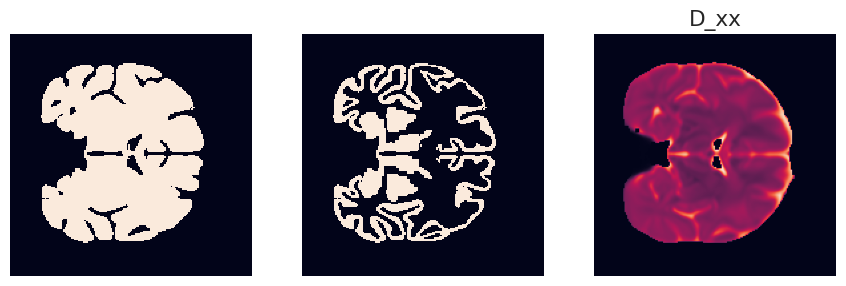

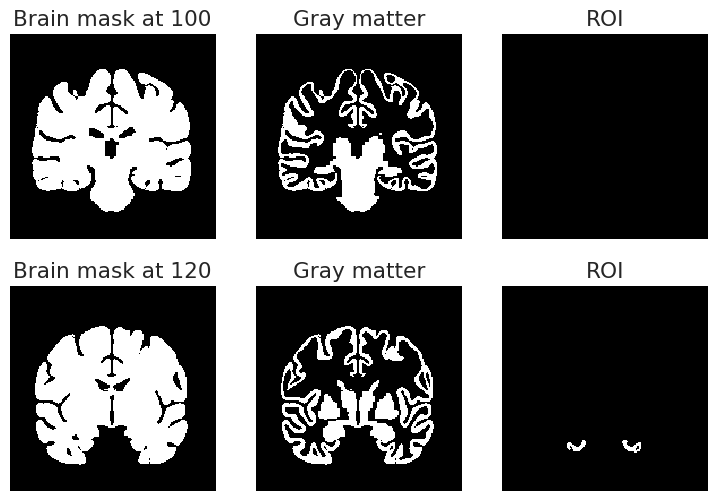

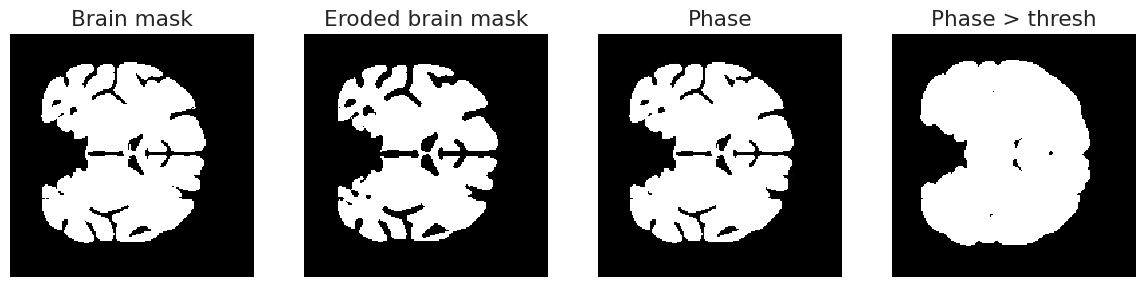

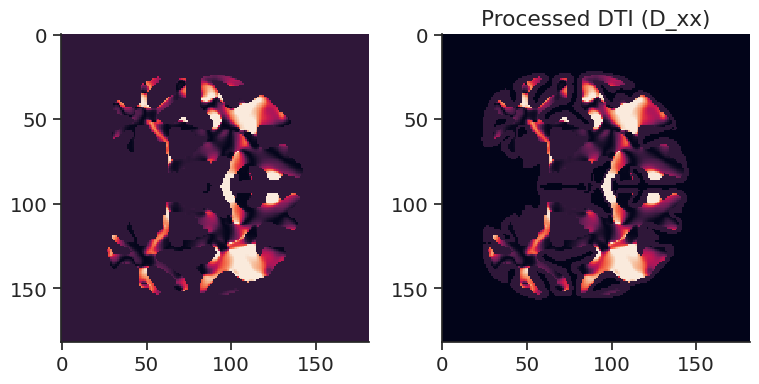

In [4]:
#
# Processing of MRI data for model parametrization
# The neuroimaging data used below are not included in this repository.
# Instructions for preparing these data will be provided in a separate document.
#
# Note: The MNI standard space provided with FSL used LAS voxel coordinates.
#
# Load masks
brain_mask = np.load(mask_load_dir / f'{ctx_atlas_setting}_brain_mask.npy')
gray_mask = np.load(mask_load_dir / f'{ctx_atlas_setting}_gray_mask.npy')
ec_mask = np.load(mask_load_dir / f'{ctx_atlas_setting}_ec_mask.npy')# Binary mask for Entorhinal cortex
# Load DTI
clean_dti = np.load(dti_load_dir / 'dti.npy')
# Load atlas label volume
atlas_label_vol = jnp.array(np.load(atlas_load_dir / f'{ctx_atlas_setting}-atlas-label.npy'), dtype=jnp.int32)

print('brain_mask: ', brain_mask.shape, brain_mask.dtype)
print('Atlas label vol: ', atlas_label_vol.shape, atlas_label_vol.dtype)

plot_dti(brain_mask, gray_mask, clean_dti, 'coronal', coronal_idx)
plot_atlas_roi(brain_mask, gray_mask, ec_mask, 'coronal', coronal_slices, k_rot90=1)

#
# Create phase field for boundary condition
#
phase = smooth_phase_boundary(brain_mask)
print('phase: ', phase.dtype, ', np.min(phase[phase > 0]): ', np.min(phase[phase > 0]))

plot_phase_field(brain_mask, phase, 'coronal', coronal_idx)
plt.savefig(save_dir / 'overview-phase-field-creation.png')

#
# Scaling and modifying Diffusion tensor field
#
dti_mode = 'anisotropic' # 'anisotropic' or 'isotropic'
scaled_clean_dti = convert_diffusion_tensor_field(convert_symmetric_diffusion_tensor_to_full(clean_dti), brain_mask, gray_mask, dti_mode)
np.save(save_dir / 'processed_clean_dti', scaled_clean_dti)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
ax[0].imshow(scaled_clean_dti[:, coronal_idx, :, 0], vmin=0, vmax=80, interpolation='nearest')
ax[1].imshow(np.multiply(scaled_clean_dti[:, coronal_idx, :, 0], brain_mask[:, coronal_idx, :]), vmin=0, vmax=80, interpolation='nearest')
plt.title('Processed DTI (D_xx)')

0  th step...
8000  th step...
16000  th step...
24000  th step...
32000  th step...
36.054110527038574 [sec]
history.shape:  (6, 182, 218, 182)


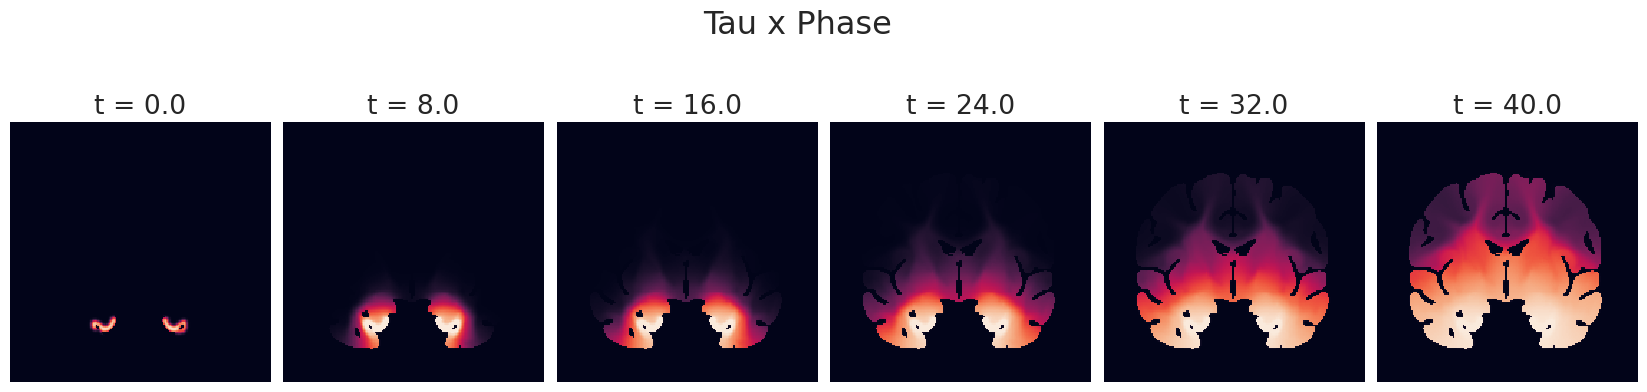

In [5]:
#
# Spatially resolved simulation of tau propagation
#
prion_init = smooth_initial_field(ec_mask)# to avoid numerical instability

t_start = time.time()
history = simulate_scan(prion_init, phase.copy(), args=[ec_mask, scaled_clean_dti, uniform_init_alpha], dt=dt, dx=dx, n_time=n_time, n_step=n_step, update_func=update_fisher_from_seed)
print(time.time() - t_start, '[sec]')# displayed time from NVIDIA RTX 6000 Ada

history = np.stack(history)
print('history.shape: ', history.shape)

sns.set_theme(style="ticks", font_scale=1.6, rc=custom_params)
plot_simulation(history, n_step*dt, 'coronal', coronal_idx, k_rot90=1, mask=phase, fig_suptitle='Tau x Phase')